# EDA

In [25]:
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import configparser

In [26]:
df = pd.read_csv('../data/AEP_hourly.csv')
df.head()

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


In [27]:
# Checking for any null row.
df.isnull().sum()

Datetime    0
AEP_MW      0
dtype: int64

In [28]:
#Converting Datetime column to datetime type
df['Datetime'] = pd.to_datetime(df['Datetime'])
df.sort_values('Datetime')
print(df['Datetime'].dtype)

datetime64[ns]


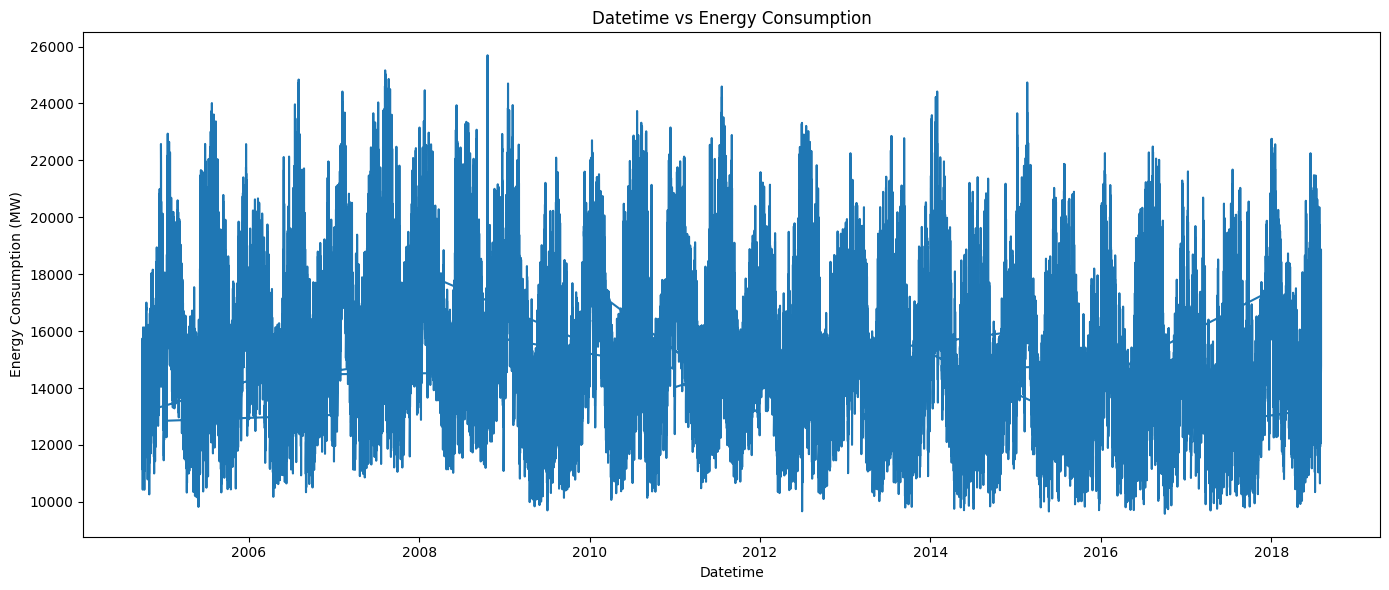

In [29]:
# Graph for datetime vs Energy consumption
plt.figure(figsize=(14, 6))
plt.plot(df['Datetime'], df['AEP_MW'])
plt.xlabel("Datetime")
plt.ylabel("Energy Consumption (MW)")
plt.title("Datetime vs Energy Consumption")
plt.tight_layout()
plt.show()

# Feature Engineering
Preprocessing raw data

In [30]:
# converting dates to year, month, day feature
df['year'] = df['Datetime'].dt.year
df['month'] = df['Datetime'].dt.month
df['day'] = df['Datetime'].dt.day
df.head()

,Datetime,AEP_MW,year,month,day
0,2004-12-31 01:00:00,13478.0,2004,12,31
1,2004-12-31 02:00:00,12865.0,2004,12,31
2,2004-12-31 03:00:00,12577.0,2004,12,31
3,2004-12-31 04:00:00,12517.0,2004,12,31
4,2004-12-31 05:00:00,12670.0,2004,12,31


In [31]:
# Converting day of the week {monday = 0 to sunday = 6} and time {hour ; minute ; seconds} to feature
df['day_of_week'] = df['Datetime'].dt.dayofweek
df['hour'] = df['Datetime'].dt.hour
df['minute'] = df['Datetime'].dt.minute
df['second'] = df['Datetime'].dt.second
df.head(100)

,Datetime,AEP_MW,year,month,day,day_of_week,hour,minute,second
0,2004-12-31 01:00:00,13478.0,2004,12,31,4,1,0,0
1,2004-12-31 02:00:00,12865.0,2004,12,31,4,2,0,0
2,2004-12-31 03:00:00,12577.0,2004,12,31,4,3,0,0
3,2004-12-31 04:00:00,12517.0,2004,12,31,4,4,0,0
4,2004-12-31 05:00:00,12670.0,2004,12,31,4,5,0,0
...,...,...,...,...,...,...,...,...,...
95,2004-12-29 00:00:00,16047.0,2004,12,29,2,0,0,0
96,2004-12-27 01:00:00,16718.0,2004,12,27,0,1,0,0
97,2004-12-27 02:00:00,16150.0,2004,12,27,0,2,0,0
98,2004-12-27 03:00:00,16090.0,2004,12,27,0,3,0,0


In [32]:
# Moving AEP_MW to last as it is y
df['AEP_MW'] = df.pop('AEP_MW')
df.head()

,Datetime,year,month,day,day_of_week,hour,minute,second,AEP_MW
0,2004-12-31 01:00:00,2004,12,31,4,1,0,0,13478.0
1,2004-12-31 02:00:00,2004,12,31,4,2,0,0,12865.0
2,2004-12-31 03:00:00,2004,12,31,4,3,0,0,12577.0
3,2004-12-31 04:00:00,2004,12,31,4,4,0,0,12517.0
4,2004-12-31 05:00:00,2004,12,31,4,5,0,0,12670.0


In [33]:
# Dropping datetime, minute and second coloumn
df.drop('Datetime',axis=1,inplace=True)
df.drop('minute',axis=1,inplace=True)
df.drop('second',axis=1,inplace=True)
df.head()

,year,month,day,day_of_week,hour,AEP_MW
0,2004,12,31,4,1,13478.0
1,2004,12,31,4,2,12865.0
2,2004,12,31,4,3,12577.0
3,2004,12,31,4,4,12517.0
4,2004,12,31,4,5,12670.0


In [35]:
# Saving the new processed dataset
# Reading config.ini
config = configparser.ConfigParser()
config.read('../config.ini')
directory = config['DATASET']['PROCESSED_DATA_DIR'] + "processed_dataset.csv"
df.to_csv("../"+directory)
print("data is cleaned and processed!")

data is cleaned and processed!
